# 1. Import Libraries & Data

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import operator

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.pyplot as figure

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
# Set path for dataset
path = '/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/'

In [3]:
# Import Scaled Weather Data
df_weather = pd.read_csv(os.path.join(path, "Dataset-scaled.csv"))

In [4]:
# Check Import
df_weather.head()

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,0,19600101,-1.599964,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,...,-0.443701,0.761754,-1.299744,-0.806427,-0.088407,-0.024706,0.372147,-0.668215,-0.519743,-0.752237
1,1,19600102,-1.599964,0.244897,-0.02793,0.735760,-0.001949,-1.058108,1.658760,-0.179228,...,0.783085,1.183580,-1.262455,-1.042055,0.503361,-0.024706,-0.829285,-0.548046,-0.629054,-0.407141
2,2,19600103,-1.599964,1.076130,-0.02793,1.277781,-0.001949,-1.251420,0.155707,-0.179228,...,0.783085,1.183580,-0.432779,-1.136306,-0.396127,-0.024706,-1.009500,-0.067372,0.054135,-0.177078
3,3,19600104,-1.599964,-1.001953,-0.02793,1.458455,-0.001949,-0.821838,-0.445514,-0.179228,...,0.783085,0.480538,0.387574,-1.183432,0.669056,-0.024706,-1.039536,-0.998679,-0.164486,-0.838511
4,4,19600105,-1.599964,0.244897,-0.02793,1.729466,-0.001949,-0.746661,-0.164944,-0.179228,...,-1.670486,-0.363113,1.729970,-0.794645,-0.490810,-0.024706,0.672505,-1.509396,-1.339569,-1.471186


In [5]:
# Import Pleasant Weather Answer Key
df_answer = pd.read_csv(os.path.join(path, "Dataset-Weather_Prediction_Pleasant_Weather.csv"))

In [6]:
# Check import
df_answer.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 2. Data Wrangling

## Reduce data down to only the year of 2010

In [7]:
df2010 = df_weather[df_weather['DATE'].astype(str).str.contains('2010')]
df2010

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
731,731,19620101,-1.599964,1.076130,-0.02793,1.910140,-0.001949,-1.251420,5.165884,-0.179228,...,-2.897272,-0.081896,0.583340,-0.747520,-0.490810,-0.024706,0.732577,-2.530829,-2.705946,-1.988830
732,732,19620102,-1.599964,1.076130,-0.02793,2.000476,-0.001949,-1.251420,-0.245107,20.257548,...,-3.510664,-0.363113,1.142672,-0.653268,-0.490810,-0.024706,0.882756,-3.311925,-3.525772,-2.650263
733,733,19620103,-1.599964,1.076130,-0.02793,2.090813,-0.001949,-1.251420,-0.205026,19.260632,...,-1.670486,-0.081896,1.273183,-1.018492,-0.490810,-0.024706,-0.408784,-3.161715,-3.553099,-2.333925
734,734,19620104,-1.599964,0.244897,-0.02793,1.819803,-0.001949,-1.251420,-0.445514,17.765258,...,-1.057093,-0.081896,1.282505,-0.782864,-0.490810,-0.024706,-0.048354,-2.320534,-3.088531,-1.643734
735,735,19620105,-1.599964,1.076130,-0.02793,2.181150,-0.001949,-1.251420,-0.445514,16.768342,...,1.396477,0.199321,0.592662,-1.183432,-0.052901,-0.024706,-1.039536,-1.929986,-2.760601,-0.752237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22650,22650,20220105,-1.599964,-0.586336,-0.02793,-0.257946,-0.766151,-0.875535,-0.405433,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22651,22651,20220106,-1.599964,0.660514,-0.02793,0.826097,0.563561,-1.090326,-0.425473,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22652,22652,20220107,-1.599964,0.660514,-0.02793,1.006770,0.441289,-1.186982,-0.044700,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22653,22653,20220108,-1.599964,0.244897,-0.02793,-0.619294,-0.766151,-1.079587,0.376155,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530


# 3. Dendrograms

## The following dendrograms are created using different linkage methods for Madrid vs. Stockholm

In [8]:
# Define cities and variables
cities = ["MADRID", "STOCKHOLM"]

variables = [
    "cloud_cover",
    "pressure",
    "global_radiation",
    "precipitation",
    "sunshine",
    "temp_mean",
    "temp_min",
    "temp_max"
]

In [9]:
feature_cols = [f"{city}_{var}" for city in cities for var in variables]

feature_cols

['MADRID_cloud_cover',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'STOCKHOLM_cloud_cover',
 'STOCKHOLM_pressure',
 'STOCKHOLM_global_radiation',
 'STOCKHOLM_precipitation',
 'STOCKHOLM_sunshine',
 'STOCKHOLM_temp_mean',
 'STOCKHOLM_temp_min',
 'STOCKHOLM_temp_max']

### 3.1 Single Method

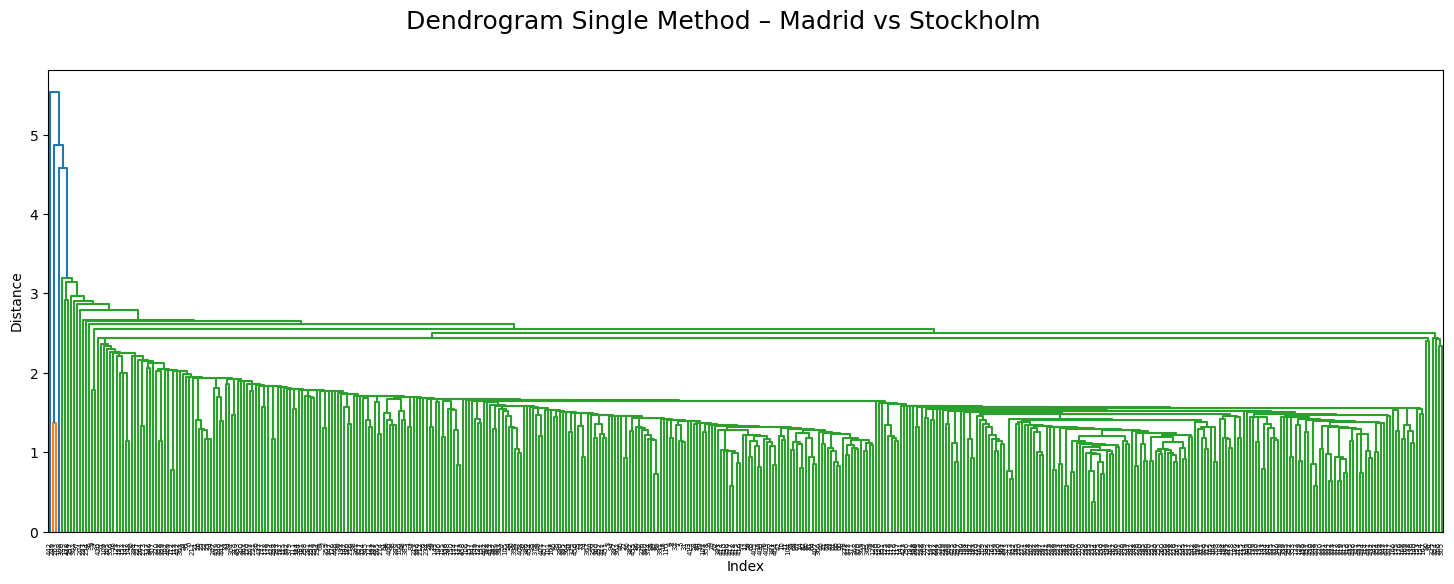

In [10]:
# Build single method dendrograms
distance_single = linkage(
    df2010.loc[:, feature_cols],
    method="single"
)
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle(
    "Dendrogram Single Method – Madrid vs Stockholm",
    fontsize=18
)
plt.show()

### 3.2 Complete Method

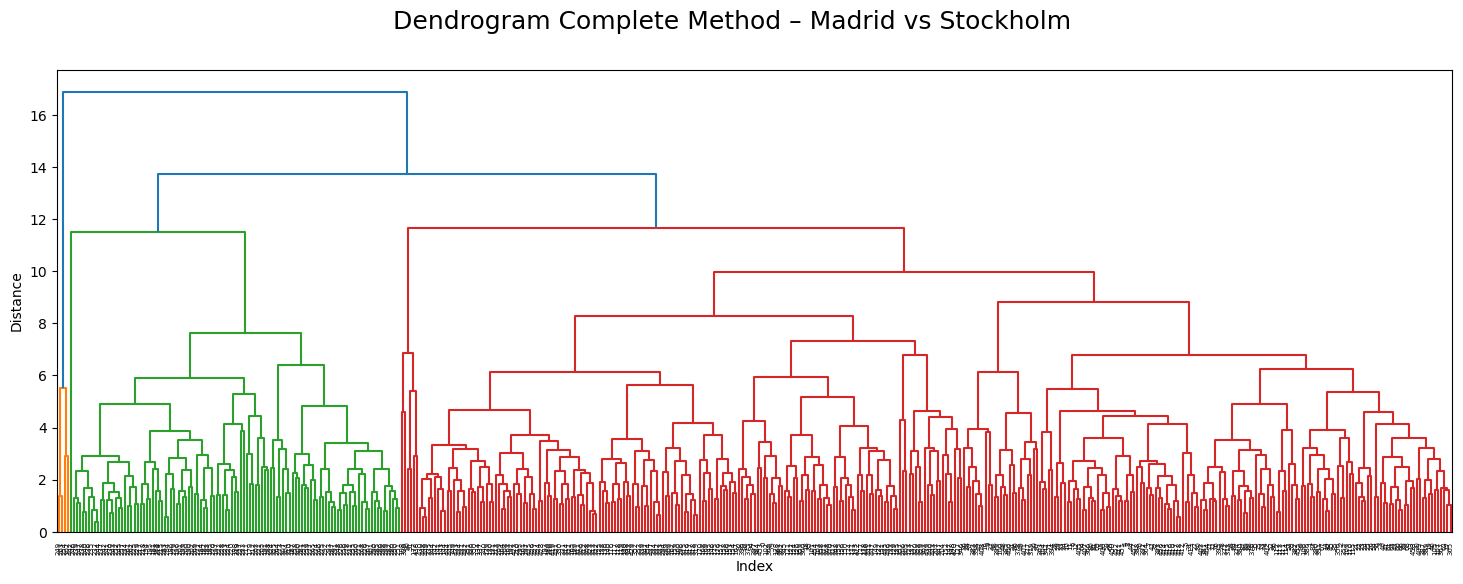

In [11]:
distance_complete = linkage(
    df2010.loc[:, feature_cols],
    method="complete"
)
plt.figure(figsize=(18, 6))
dendrogram(distance_complete, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Complete Method – Madrid vs Stockholm", fontsize=18)
plt.show()

### 3.3 Average Method

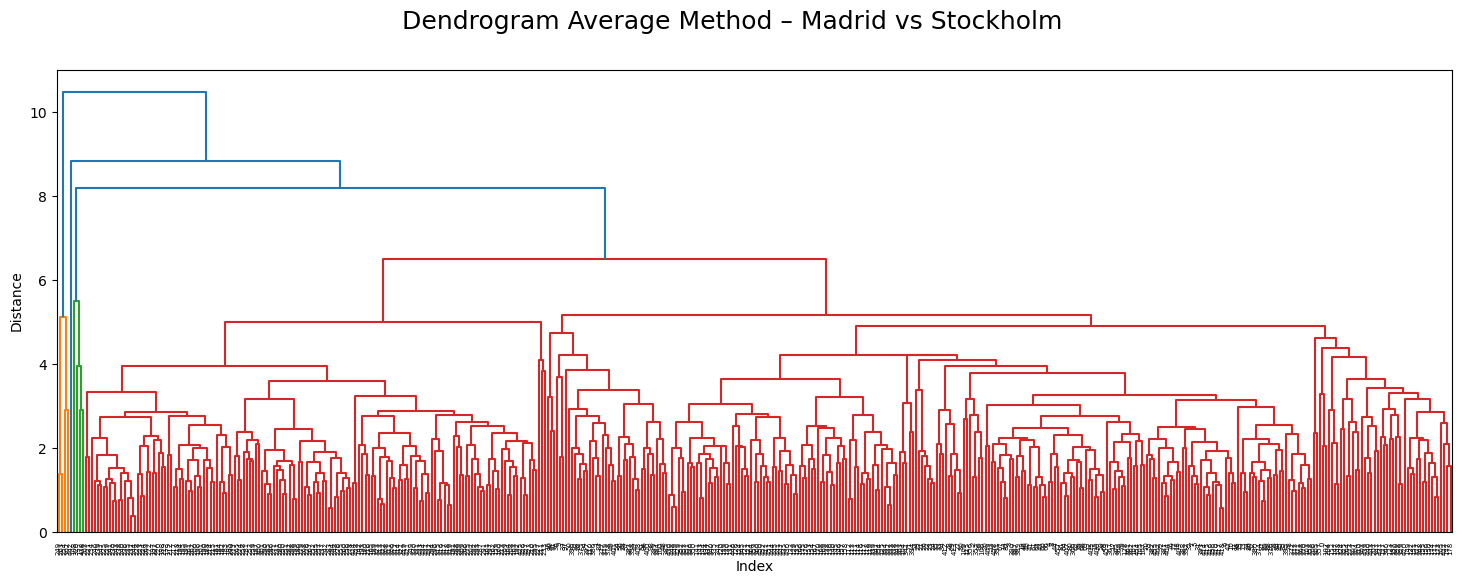

In [12]:
distance_average = linkage(
    df2010.loc[:, feature_cols],
    method="average"
)
plt.figure(figsize=(18, 6))
dendrogram(distance_average, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Average Method – Madrid vs Stockholm", fontsize=18)
plt.show()

### 3.4 Ward Method

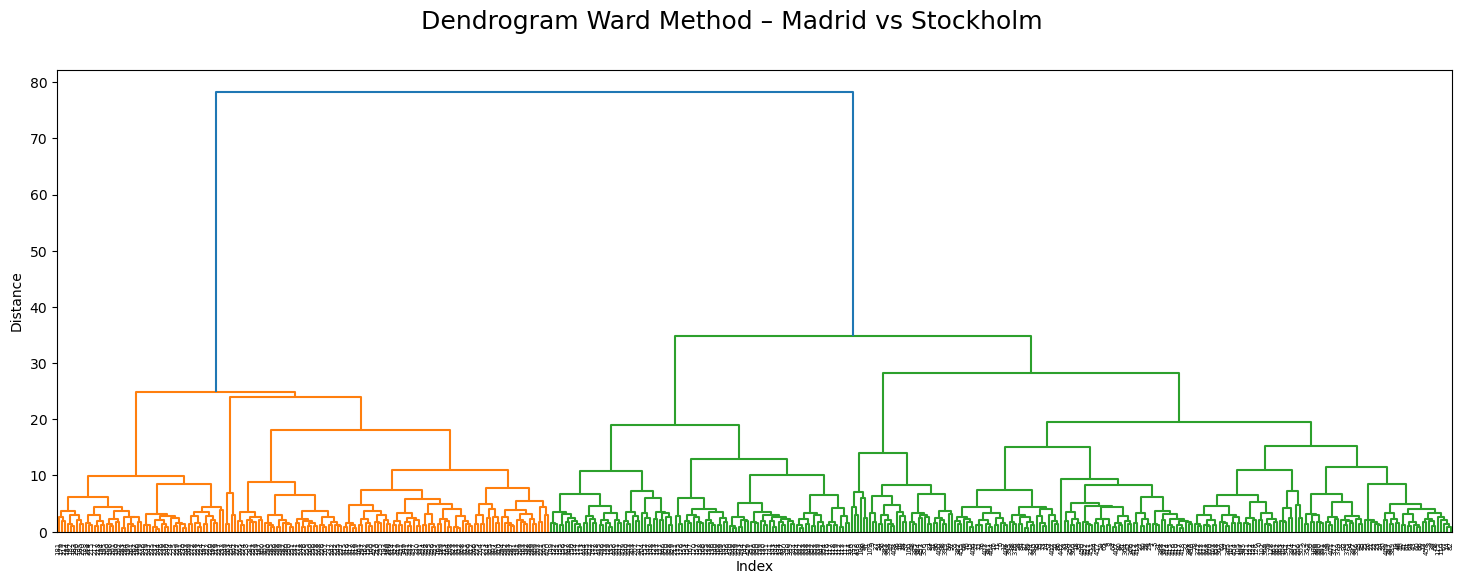

In [13]:
distance_ward = linkage(
    df2010.loc[:, feature_cols],
    method="ward"
)
plt.figure(figsize=(18, 6))
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Ward Method – Madrid vs Stockholm", fontsize=18)
plt.show()

# 4. Principle Component Analysis (PCA)

In [14]:
# Filter the pleasant weather key to only year 2010
df_answer2010 = df_answer[df_answer["DATE"].astype(str).str.contains("2010")].copy()

# reset index
df_answer2010 = df_answer2010.reset_index(drop=True)

In [15]:
# Pick stations
stations = ["MADRID", "STOCKHOLM"]

In [16]:
# Identify non-feature columns
non_feature_cols = [c for c in ["DATE", "MONTH"] if c in df2010.columns]

# Remove pleasant weather labels if present in df2010
pleasant_cols = [c for c in df2010.columns if "pleasant_weather" in c]

# Build feature matrix for PCA
X2010 = df2010.drop(columns=non_feature_cols + pleasant_cols, errors="ignore")

# Check output
X2010.shape

(459, 169)

In [17]:
# Use 9 as number of components
pca = PCA(n_components=9, random_state=42)

PC = pca.fit_transform(X2010)

# Create PCA dataframe
dfPCA = pd.DataFrame(
    PC,
    columns=[f"PCA{i}" for i in range(1, PC.shape[1] + 1)]
)

dfPCA.head()

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9
0,-17041.038591,-1.873935,0.612774,-4.632518,13.091143,0.120973,1.536458,17.843235,-6.312618
1,-17040.046460,1.908079,0.340030,-1.216894,15.865732,0.646523,8.449269,13.342347,7.983645
2,-17039.047706,2.110778,0.175464,1.743950,13.522387,3.388092,9.442196,12.847997,9.153241
3,-17038.042889,0.900910,-0.831126,1.674328,2.790055,0.792878,5.107859,-1.450558,10.107448
4,-17037.041555,0.583608,-0.669725,0.329602,-0.255433,-0.357474,4.815378,-4.141792,9.626487


In [19]:
print("Explained variance ratio:")
print(np.round(pca.explained_variance_ratio_, 4))

print("\nCumulative explained variance:")
print(np.round(np.cumsum(pca.explained_variance_ratio_), 4))

Explained variance ratio:
[1. 0. 0. 0. 0. 0. 0. 0. 0.]

Cumulative explained variance:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
# Export PCA dataset
dfPCA.to_csv(os.path.join(path, '2010_PCA.csv'), index=False)

# 5. Dendrograms with PCA

## 5.1 Single Method

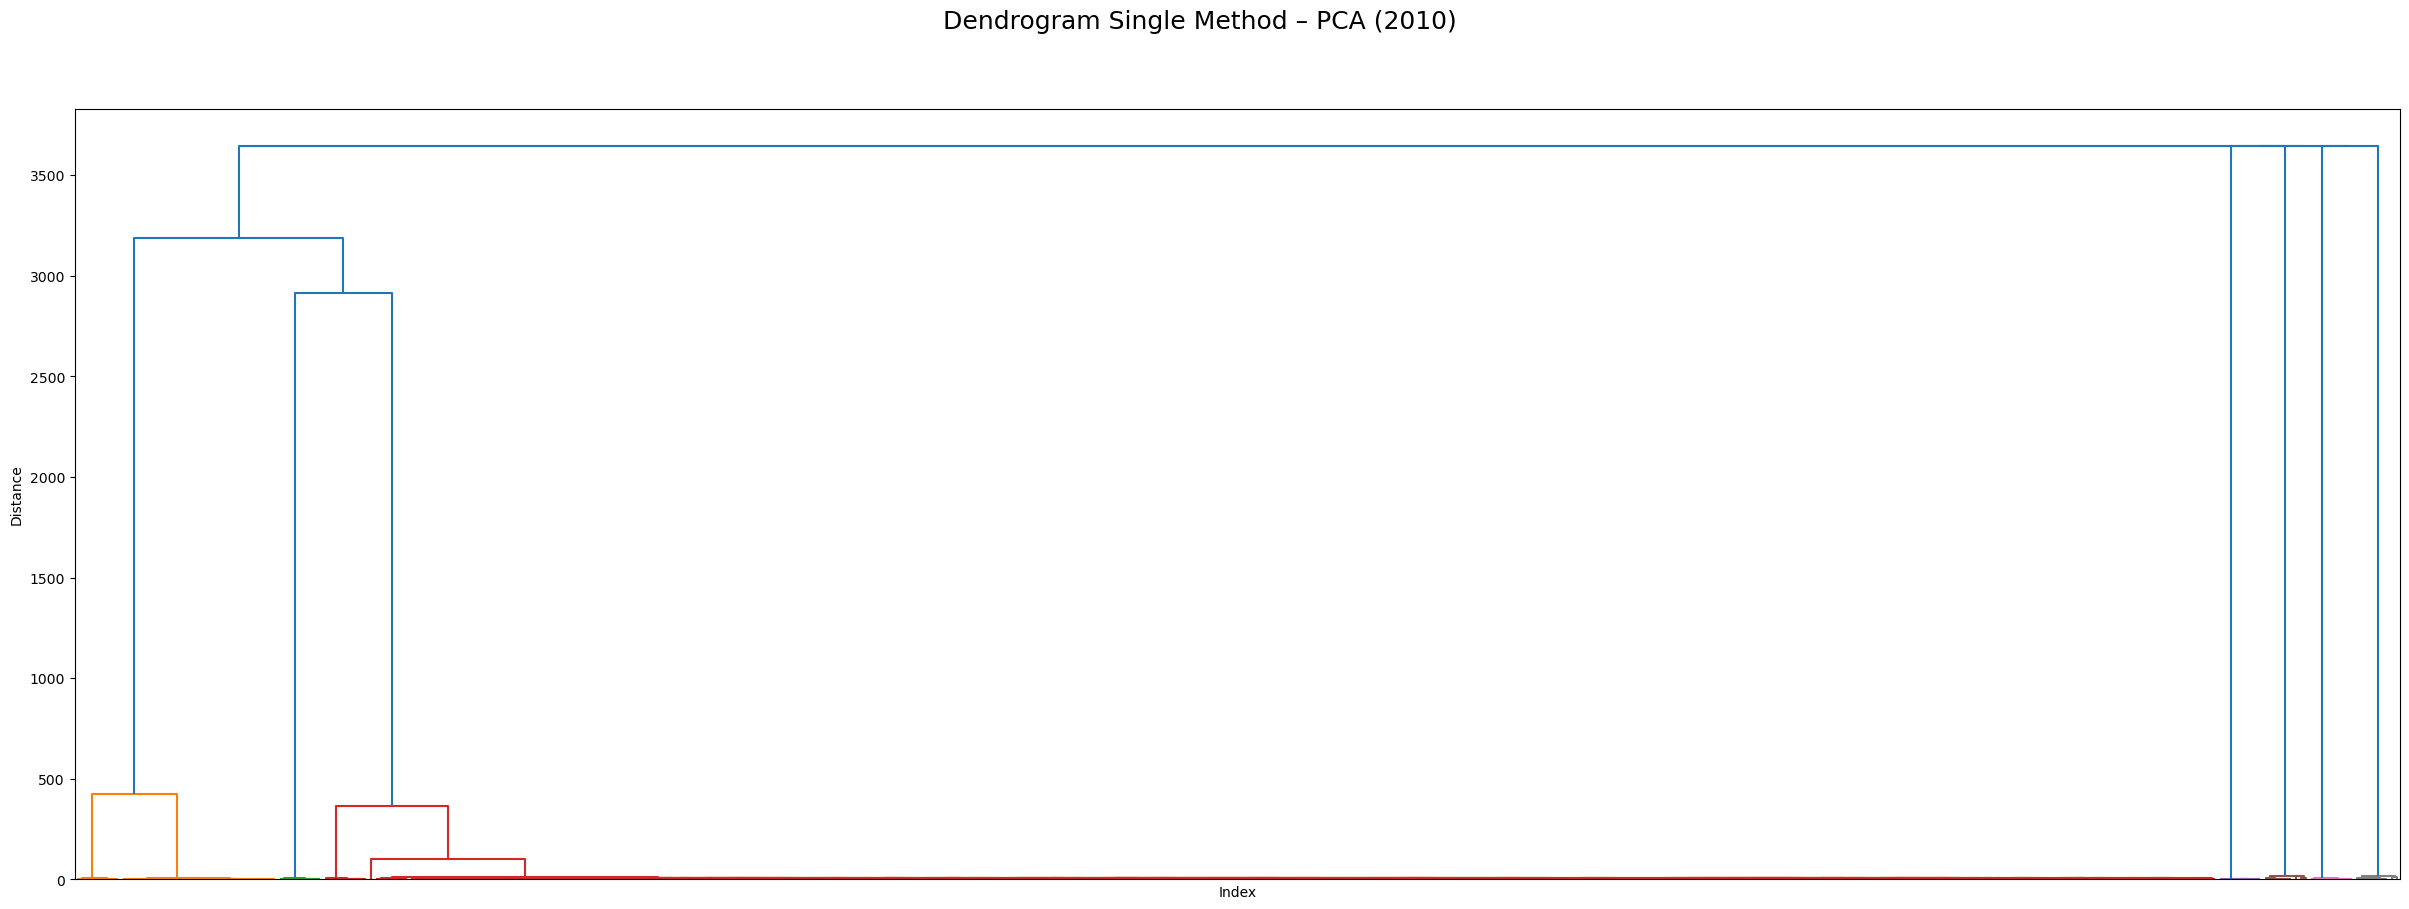

In [22]:
Z_single_pca = linkage(dfPCA.values, method="single")

plt.figure(figsize=(30, 10))
dendrogram(Z_single_pca, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Single Method – PCA (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/PCA_Single.png"
plt.savefig(save_path, dpi=300)
plt.show()

**PCA Dendrogram - Single Method**

The single-linkage dendrogram in PCA space exhibits a pronounced chaining effect, with most observations merging at very low distances and a small number of extreme merges occurring at high distances. This structure indicates that single linkage remains sensitive to nearest-neighbor connections even after dimensionality reduction and does not produce clearly separable clusters in the reduced PCA space.

## 5.2 Complete Method

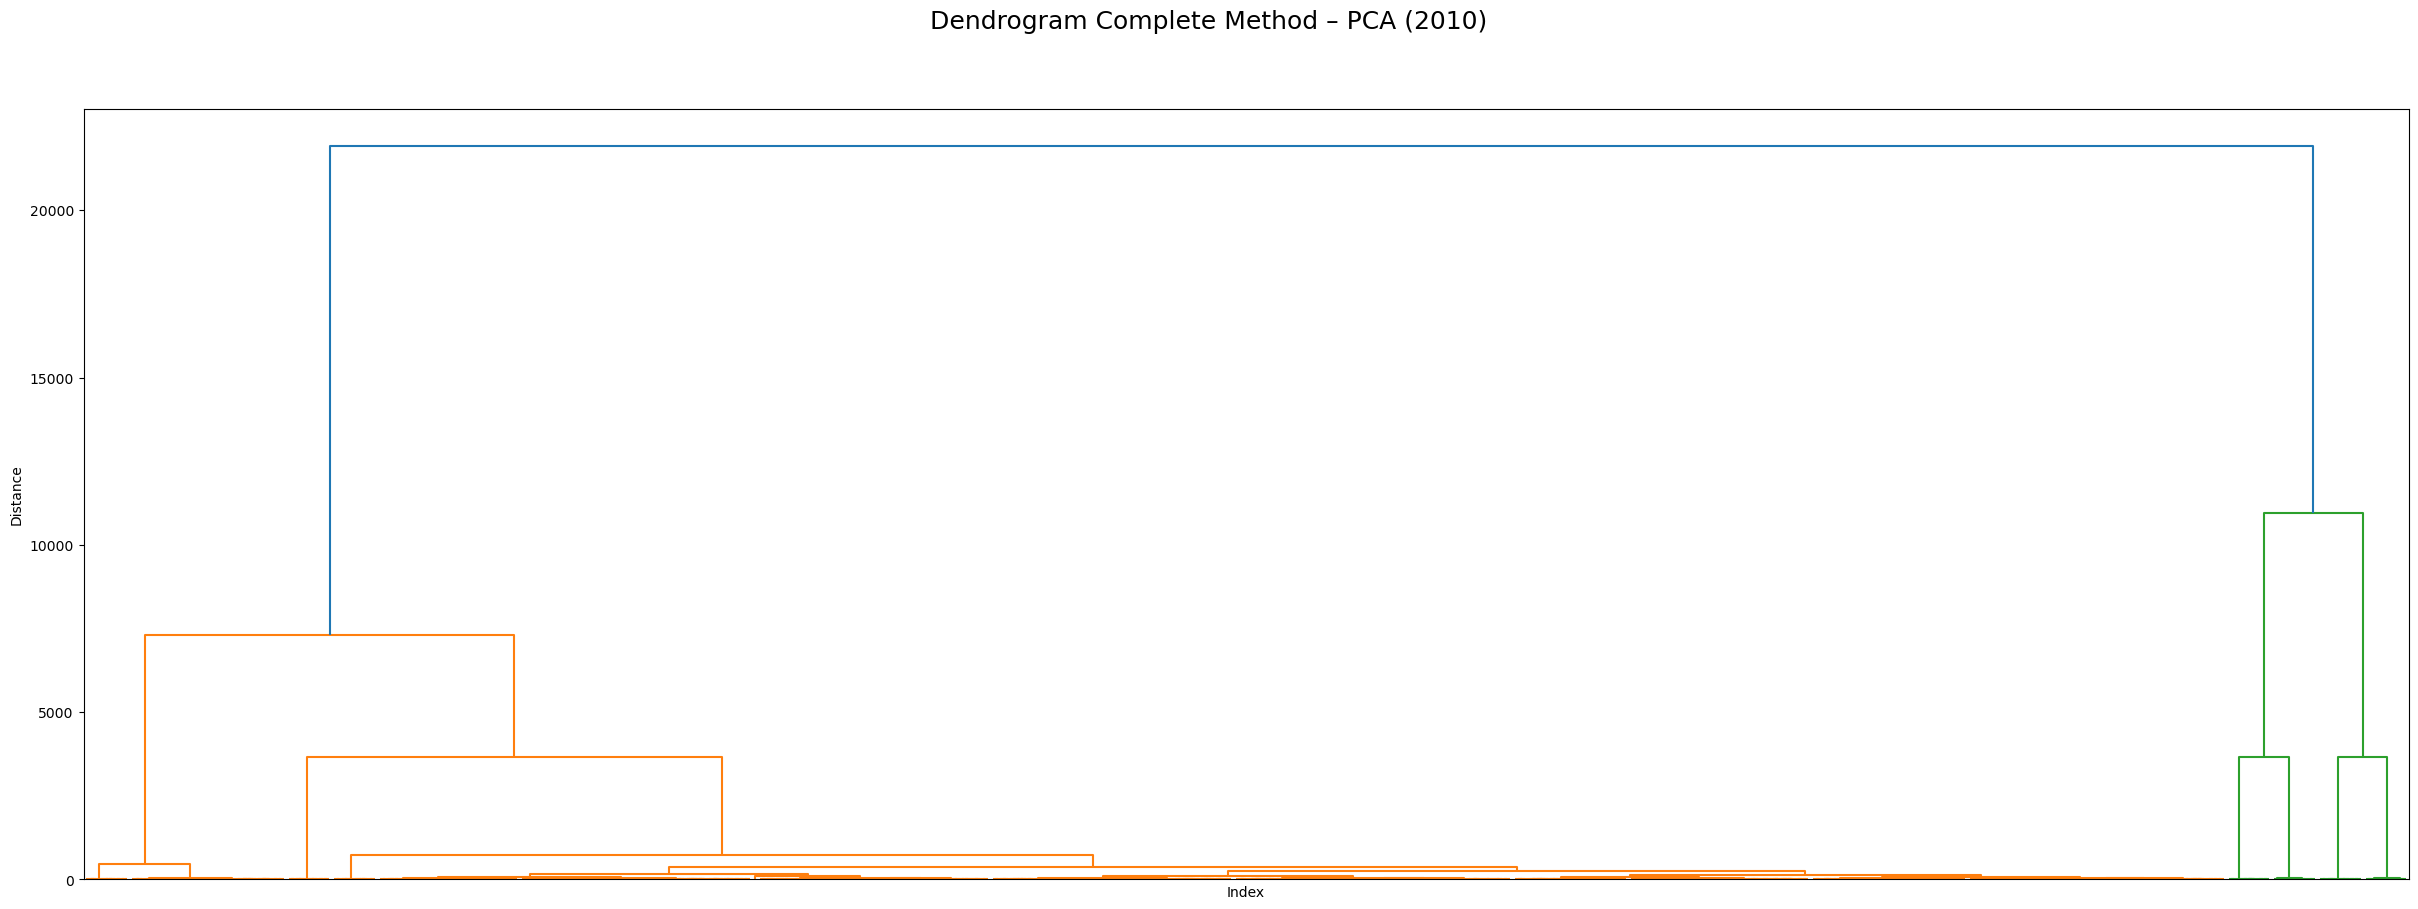

In [23]:
Z_complete_pca = linkage(dfPCA.values, method="complete")

plt.figure(figsize=(30, 10))
dendrogram(Z_complete_pca, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Complete Method – PCA (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/PCA_Complete.png"
plt.savefig(save_path, dpi=300)
plt.show()

**PCA Dendrogram - Complete Method**

The complete-linkage dendrogram in PCA space reveals a clear high-level separation, with clusters merging only at large linkage distances. Compared to single linkage, complete linkage produces more compact and well-separated clusters after dimensionality reduction, which indicates that PCA enhances the interpretability of cluster structure under this method.

# 5.3 Average Method

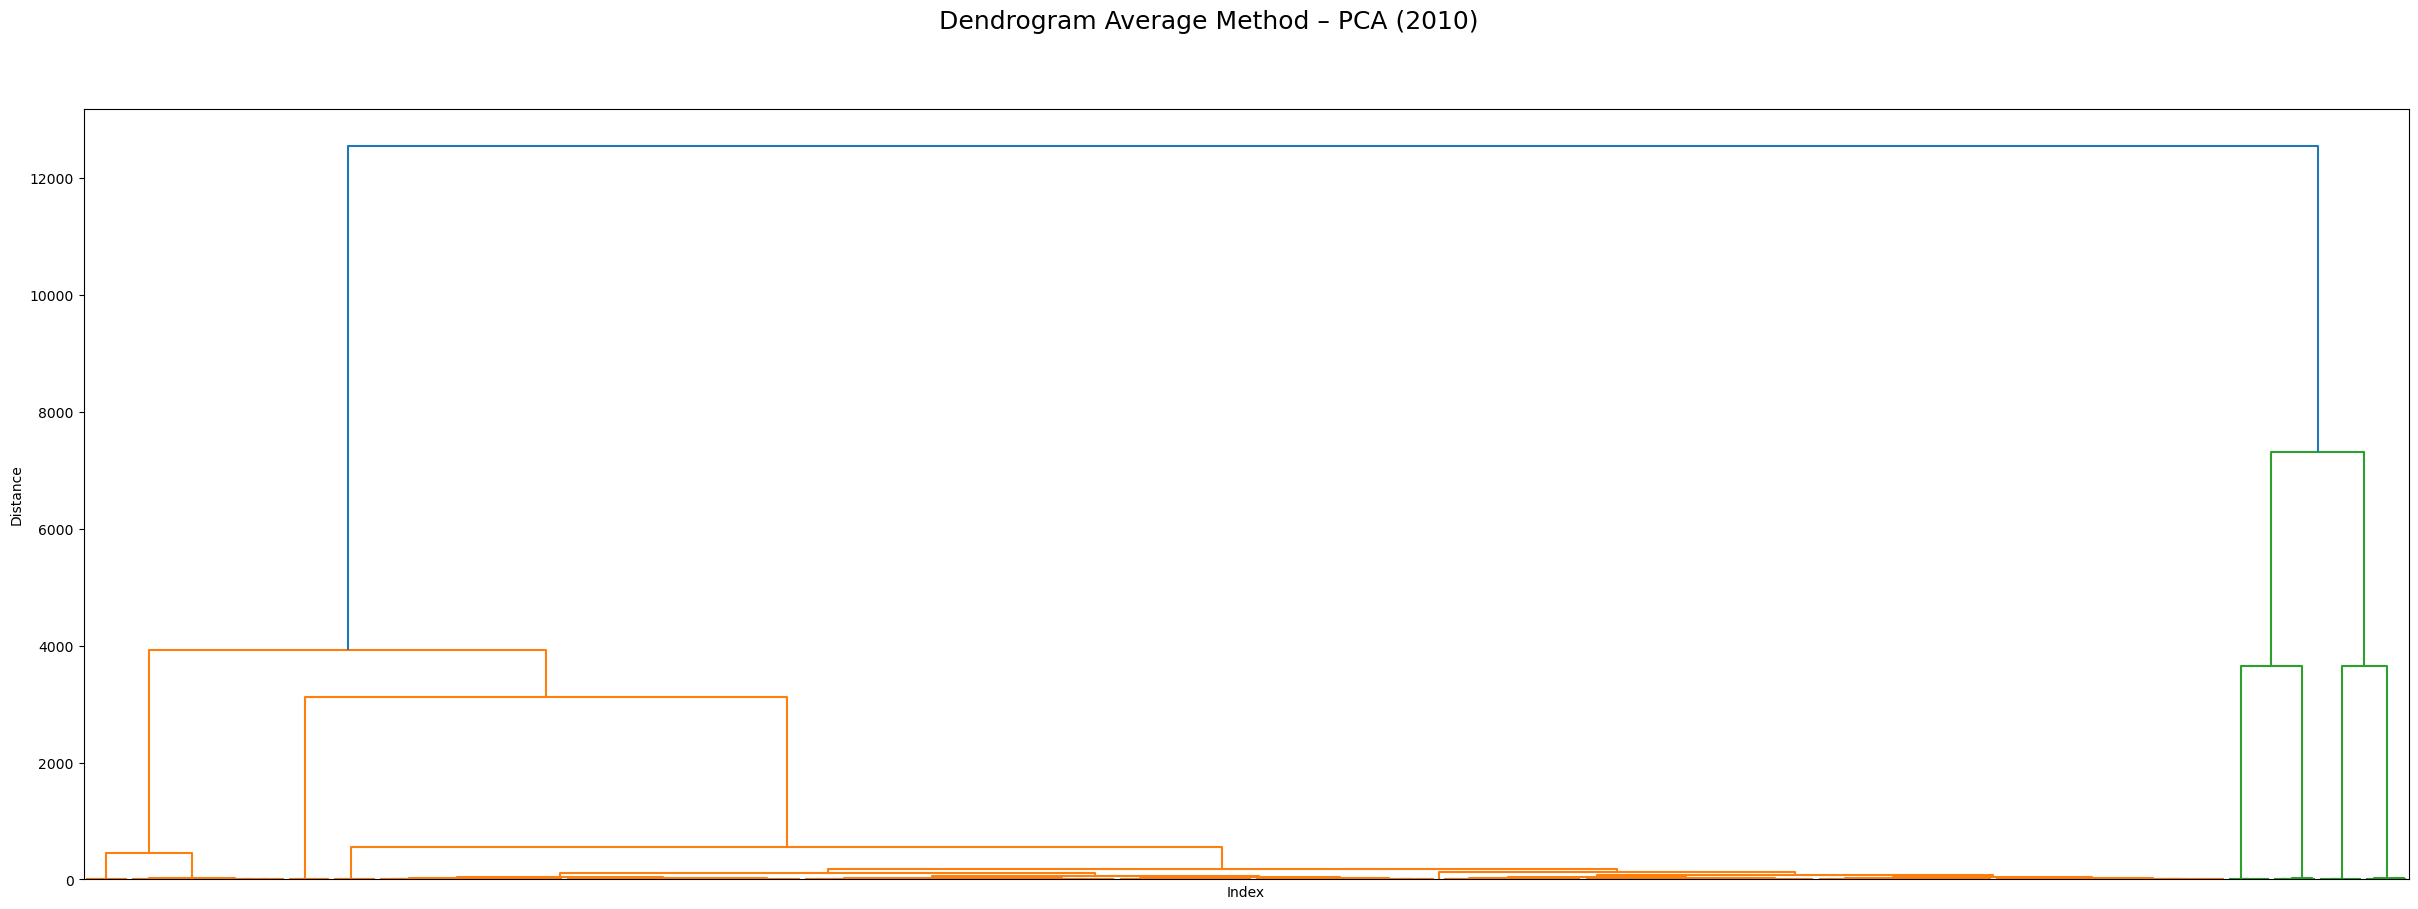

In [24]:
Z_average_pca = linkage(dfPCA.values, method="average")

plt.figure(figsize=(30, 10))
dendrogram(Z_average_pca, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Average Method – PCA (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/PCA_Average.png"
plt.savefig(save_path, dpi=300)
plt.show()

**PCA Dendrogram - Average Method**

The average-linkage dendrogram in PCA space displays a clear macro-level separation with more gradual cluster merging than complete linkage. This pattern suggests that average linkage captures broad weather regimes while allowing smoother transitions between clusters. This reflects overlapping climatic conditions even after dimensionality reduction.

## 5.4 Ward Method

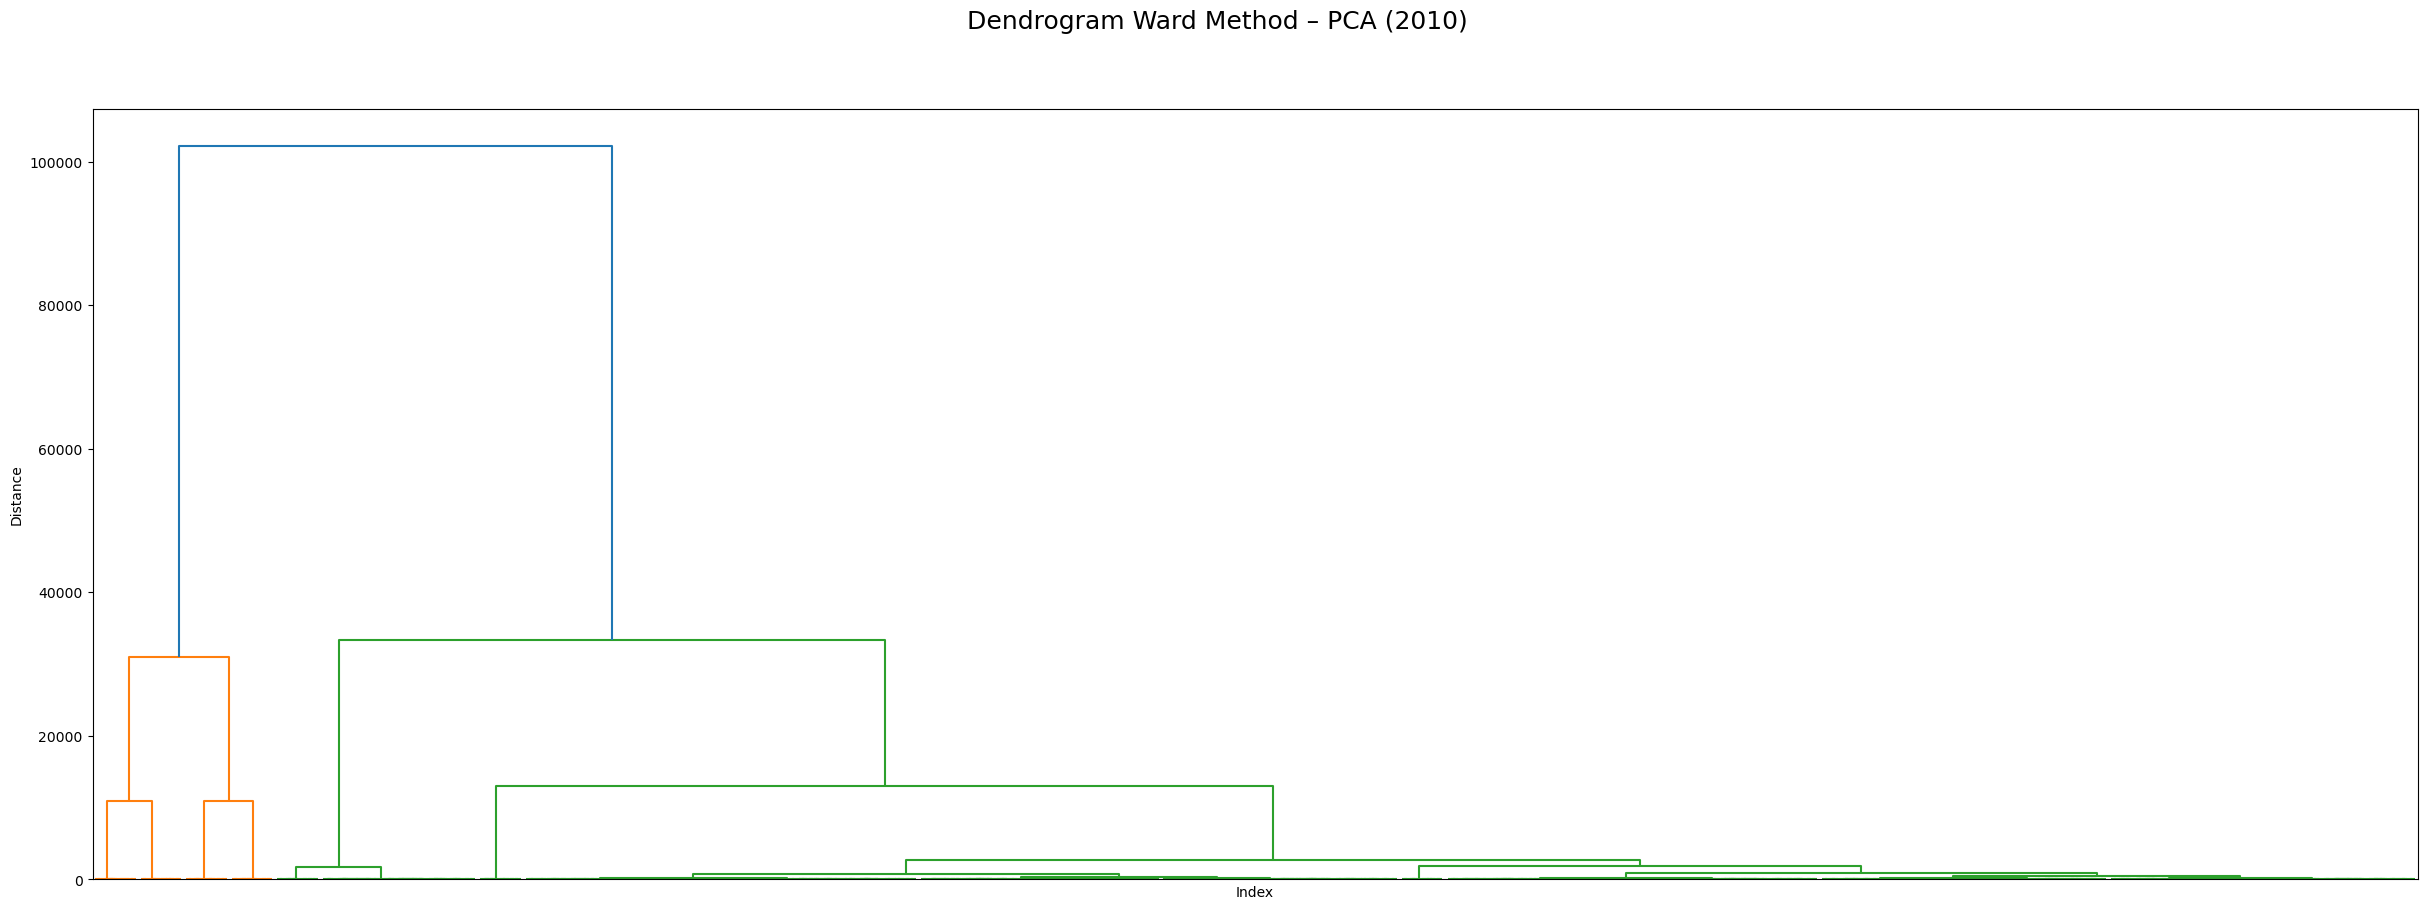

In [26]:
Z_ward_pca = linkage(dfPCA.values, method="ward")

plt.figure(figsize=(30, 10))
dendrogram(Z_ward_pca, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Ward Method – PCA (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/PCA_Ward.png"
plt.savefig(save_path, dpi=300)
plt.show()

**PCA Dendrogram - Ward Method**

The Ward-linkage dendrogram in PCA space exhibits the most distinct and interpretable clustering structure, with clear hierarchical separation and large jumps in linkage distance at higher levels. This indicates that Ward’s method, combined with PCA, effectively groups observations by minimizing within-cluster variance and reveals dominant weather pattern regimes in the reduced-dimensional space.

# 6. PCA and Clusters Comparison


MADRID — cluster vs label
label      0    1
cluster          
1         36    0
2        252  171


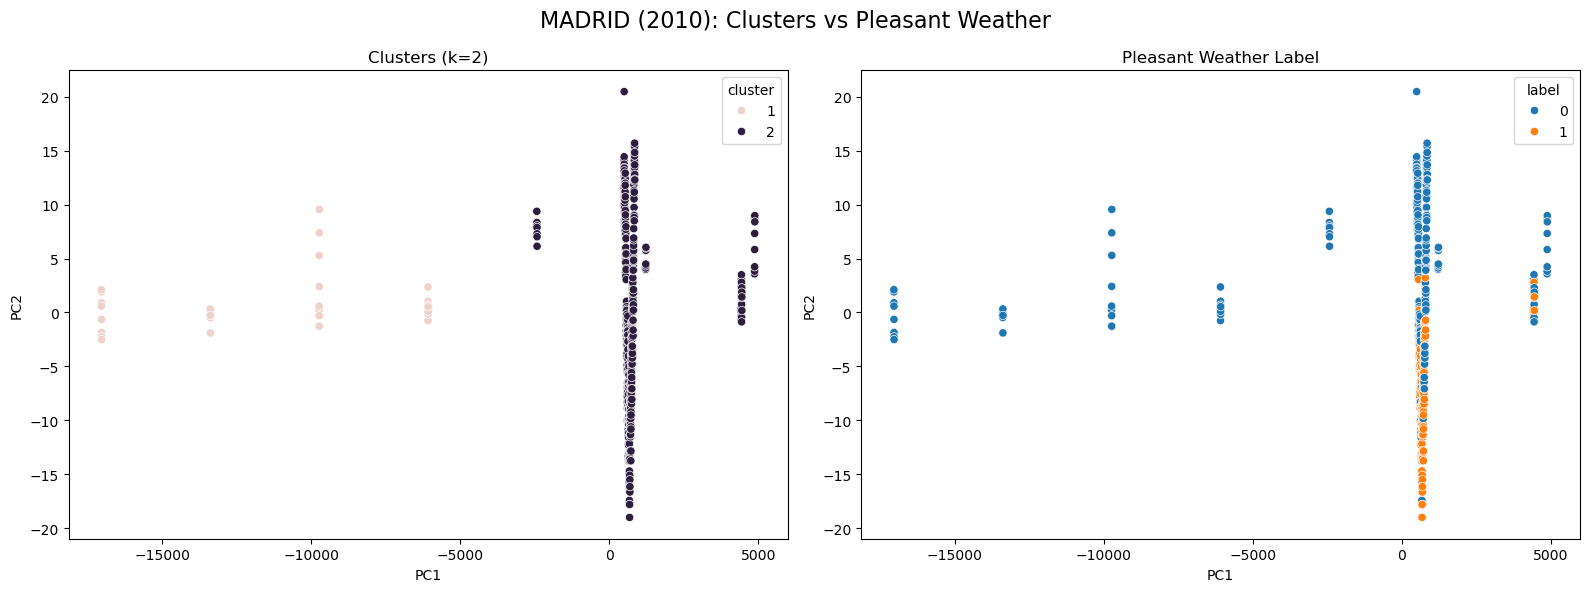


STOCKHOLM — cluster vs label
label      0   1
cluster         
1         36   0
2        357  66


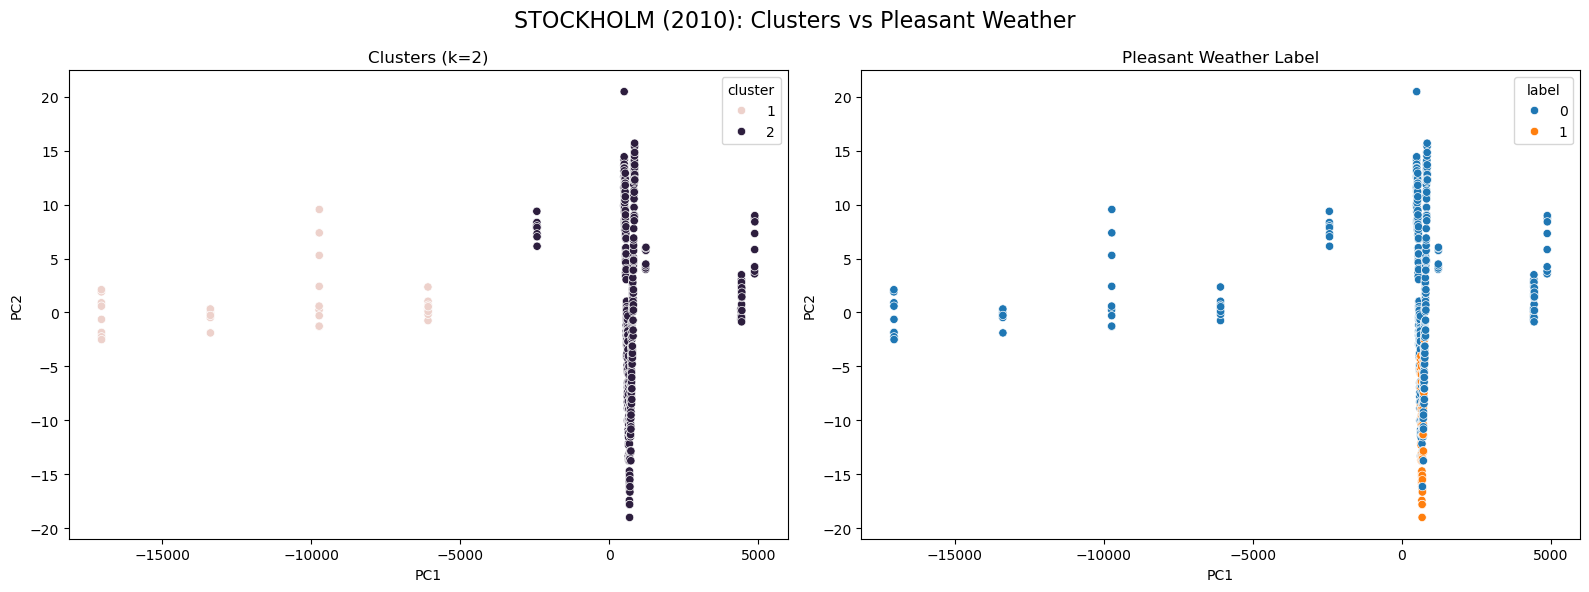

In [28]:
clusters2 = fcluster(Z_ward_pca, 2, criterion="maxclust")

for st in stations:
    label_col = f"{st}_pleasant_weather"
    if label_col not in df_answer2010.columns:
        continue

    df_plot = pd.DataFrame({
        "PC1": dfPCA["PCA1"],
        "PC2": dfPCA["PCA2"],
        "cluster": clusters2,
        "label": df_answer2010[label_col].astype(int)
    })

    print(f"\n{st} — cluster vs label")
    print(pd.crosstab(df_plot["cluster"], df_plot["label"]))

    plt.figure(figsize=(16,6))
    plt.suptitle(f"{st} (2010): Clusters vs Pleasant Weather", fontsize=16)

    plt.subplot(1,2,1)
    sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="cluster")
    plt.title("Clusters (k=2)")

    plt.subplot(1,2,2)
    sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="label")
    plt.title("Pleasant Weather Label")

    plt.tight_layout()
    plt.show()


#### Across both Madrid and Stockholm, hierarchical clustering (k=2) in PCA space identifies one cluster composed exclusively of non-pleasant days, while all pleasant days are contained within a broader mixed cluster. This suggests that extreme or clearly unfavorable weather forms a distinct meteorological regime, whereas pleasant weather does not constitute a separate cluster but rather occurs within a range of typical conditions.